In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.integrate import quad

from label_lines import *
from matplotlib import rc, rcParams 
import random
E_CR=1e+50 #ergs
Esn=1e+51 #ergs
E_th=0.2797 #GeV
D0=3e+26 #cm^2s^-1
delta=0.5
c=3e+10
k=0.45
Rc=10 #pc
Resc=30
tesc=1600 #yr
alpha=2
E0=1 #Gev
X=1000 #pc
#parameters that can be varied
n=1 #cm^-3
tsnr=8000 #yr
d=32 #pc
def N0(E_CR, E_min, E_max, alpha):
    if alpha == 2:
        return E_CR / (np.log(E_max) - np.log(E_min))
    else:
        return E_CR * (2 - alpha) / (E_max**(2-alpha) - E_min**(2-alpha))
        
def sigma_pp(E):
   
    if E < E_th:
        return 0.0

    log_term = np.log(E / E_th)
    term1 = 30.7 - 0.96 * log_term + 0.18 * log_term**2
    
    # Compute the energy-dependent factor
    term2 = (1 - (E_th / E)**1.9)**3
    
    # Total cross-section in mbarn
    sigma = term1 * term2
    return sigma
def tau_pp(E, n):
    sigma = sigma_pp(E) * mbarn_to_cm2  # Convert mbarn to cm^2
    
    # Compute tau_pp = [n * c * k * sigma]^(-1)
    denominator = n * c * k * sigma
    if denominator == 0:
        return float('inf')  # Avoid division by zero
    tau = 1 / denominator
    return tau

def R_SNR(t):
    numerator=0.31*((Esn/1e15)**(1/5))*(t**(2/5))
    denominator=(n*(mu1/1.4))**(1/5)
    R_SNR=numerator/denominator
    return R_SNR
def R_prime(d):
     R_prime=d-Rc-Resc
     return R_prime
def t_prime(tsnr):
    t_prime=tsnr_tesc
    return t_prime

def D(E):
    chi=1
    D_val = chi * D0 * (E * 1e3)**delta  # if E is in TeV and D0 in GeV
    return D_val

def R_d(E, t_prime):
    return 2*np.sqrt(D(E)*t_prime)
    
def f0(R_d, R_SNR):
    numerator = np.sqrt(np.pi) * R_d(E, t_prime)**3
    term1 = np.sqrt(np.pi) * R_d(E, t_prime)**2 + 2 * np.sqrt(np.pi) * R_SNR**2
    term2= term1*R_d(E, t_prime)
    term3 = 4 * R_SNR**2 * R_d(E, t_prime)**2
    denominator = term2 + term3
    
    # Avoid division by zero
    if denominator == 0:
        return 0.0
    
    # Compute f_0
    f0 = numerator / denominator
    return f0

def f(E, R_prime, t_prime):
    prefactor = f0 / (np.pi**(3/2) * R_d(E, t_prime)**3)
    exponent = -((alpha - 1) * t_prime / tau_pp) - (R_prime**2 / R_d(E, t_prime)**2)
    return prefactor * np.exp(exponent)

def Jp(E,R,t):
 return N0 * (E ** -alpha) * f(E, R, t)
def Phi_gamma(E_gamma, R_prime, t_prime):
    integrand = lambda E: sigma_pp(E) * f(E, R_prime, t_prime) * F_gamma(E_gamma / E, E) / E
    integral, _ = quad(integrand, E_gamma, np.inf, limit=100)
    return c * n * integral  # in ph cm^-3 s^-1 TeV^-1

# Gamma-ray flux
def F_gamma_obs(E_gamma, R_prime, t_prime, Vc, X):
    phi = Phi_gamma(E_gamma, R_prime, t_prime)
    return phi * Vc / (4 * np.pi * X**2)  # in ph cm^-2 s^-1 TeV^-1
E_gamma = np.logspace(-5, 3, 100)   #in TeV
E2_dNdE = [E**2 * F_gamma_obs(E, R_prime, t_prime, Vc, X) for E in E_gamma]
plt.figure(figsize=(8, 6))
plt.loglog(E_gamma_values, E2_dNdE, label=r'$E^2 \cdot dN/dE$')
plt.xlabel('Energy $E$ [TeV]')
plt.ylabel(r'$E^2 \cdot \frac{dN}{dE}$ [TeV cm$^{-2}$ s$^{-1}$]')
plt.title('Gamma-ray Spectral Energy Distribution')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for *: 'float' and 'function'

<>:107: SyntaxWarning: invalid escape sequence '\g'
<>:107: SyntaxWarning: invalid escape sequence '\g'
C:\Users\91898\AppData\Local\Temp\ipykernel_19268\1003998149.py:107: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel('Energy $E_\gamma$ [TeV]')


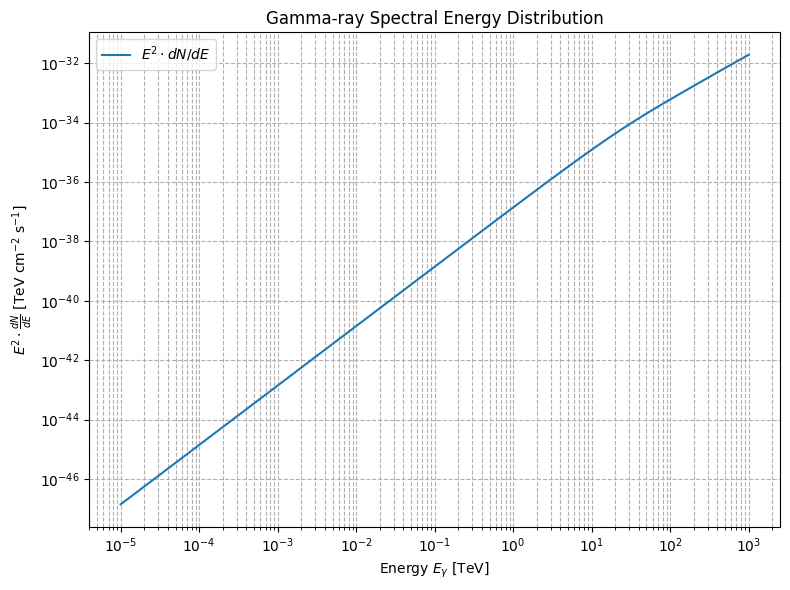

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Constants
E_CR = 1e+50        # ergs
Esn = 1e+51         # ergs
E_th = 0.2797       # GeV
D0 = 3e+26          # cm^2 s^-1
delta = 0.5
c = 3e+10           # cm/s
k = 0.45
Rc = 10             # pc
Resc = 30           # pc
tesc = 1600         # yr
alpha = 2
E0 = 1              # GeV
X = 1000            # pc
n = 1               # cm^-3
tsnr = 8000         # yr
d = 32              # pc

# Additional conversions and parameters
mbarn_to_cm2 = 1e-27
mu1 = 1.4
Vc = 4/3 * np.pi * (Rc * 3.086e18)**3  # Rc in pc, converted to cm

# Energy grid in TeV
E_gamma = np.logspace(-5, 3, 100)   # TeV

# Function Definitions
def N0(E_CR, E_min, E_max, alpha):
    if alpha == 2:
        return E_CR / (np.log(E_max) - np.log(E_min))
    else:
        return E_CR * (2 - alpha) / (E_max**(2 - alpha) - E_min**(2 - alpha))

def sigma_pp(E):
    if E < E_th:
        return 0.0
    log_term = np.log(E / E_th)
    term1 = 30.7 - 0.96 * log_term + 0.18 * log_term**2
    term2 = (1 - (E_th / E)**1.9)**3
    sigma = term1 * term2  # in mbarn
    return sigma

def tau_pp(E, n=n):
    sigma = sigma_pp(E) * mbarn_to_cm2
    denominator = n * c * k * sigma
    return 1 / denominator if denominator != 0 else float('inf')

def R_SNR(t):
    t_sec = t * 3.15e7  # Convert years to seconds
    numerator = 0.31 * ((Esn / 1e15)**(1/5)) * (t_sec**(2/5))
    denominator = (n * (mu1 / 1.4))**(1/5)
    return numerator / denominator  # in cm

def R_prime(d):
    return (d - Rc - Resc) * 3.086e18  # Convert pc to cm

def t_prime(tsnr):
    return (tsnr - tesc) * 3.15e7  # years to seconds

def D(E):
    chi = 1
    return chi * D0 * (E * 1e3)**delta  # E in TeV → GeV

def R_d(E, t_prime_val):
    return 2 * np.sqrt(D(E) * t_prime_val)

def f0(R_d_val, R_SNR_val):
    numerator = np.sqrt(np.pi) * R_d_val**3
    term1 = np.sqrt(np.pi) * R_d_val**2 + 2 * np.sqrt(np.pi) * R_SNR_val**2
    term2 = term1 * R_d_val
    term3 = 4 * R_SNR_val**2 * R_d_val**2
    denominator = term2 + term3
    return numerator / denominator if denominator != 0 else 0.0

# Placeholder gamma-ray production function
def F_gamma(x, E):
    return np.exp(-x)  # crude approximation

def f(E, R_prime_val, t_prime_val):
    R_d_val = R_d(E, t_prime_val)
    R_SNR_val = R_SNR(t_prime_val / 3.15e7)  # convert sec to yr for SNR radius
    prefactor = f0(R_d_val, R_SNR_val) / (np.pi**(3/2) * R_d_val**3)
    exponent = -((alpha - 1) * t_prime_val / tau_pp(E)) - (R_prime_val**2 / R_d_val**2)
    return prefactor * np.exp(exponent)

def Phi_gamma(E_gamma, R_prime_val, t_prime_val):
    integrand = lambda E: sigma_pp(E) * f(E, R_prime_val, t_prime_val) * F_gamma(E_gamma / E, E) / E
    integral, _ = quad(integrand, E_gamma, 1e5, limit=100)
    return c * n * integral  # ph cm^-3 s^-1 TeV^-1

def F_gamma_obs(E_gamma, R_prime_val, t_prime_val, Vc, X):
    phi = Phi_gamma(E_gamma, R_prime_val, t_prime_val)
    return phi * Vc / (4 * np.pi * (X * 3.086e18)**2)  # convert X to cm

# Compute and Plot
t_p = t_prime(tsnr)
r_p = R_prime(d)

E2_dNdE = [E**2 * F_gamma_obs(E, r_p, t_p, Vc, X) for E in E_gamma]

plt.figure(figsize=(8, 6))
plt.loglog(E_gamma, E2_dNdE, label=r'$E^2 \cdot dN/dE$')
plt.xlabel('Energy $E_\gamma$ [TeV]')
plt.ylabel(r'$E^2 \cdot \frac{dN}{dE}$ [TeV cm$^{-2}$ s$^{-1}$]')
plt.title('Gamma-ray Spectral Energy Distribution')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.tight_layout()
plt.show()
